# Inverse Modeling example

We'll show a simple example for inverse modeling using automatic differentiation on a vertex model with periodic boundary conditions.

First, let's check that VertAX is correctly installed by importing all we'll need for the next parts
coucou

In [1]:
from vertax import PbcBilevelOptimizer, PbcMesh
# We'll see how to those important classes.

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Now, let's create our initial mesh. It will have 20 cells, in a square domain.

In [2]:
import math

# Settings
n_cells = 20
# Square domain that can contains 20 cells of area 1.
width = math.sqrt(n_cells)
height = width

# Create a new mesh with periodic boundary conditions, from an initial Voronoi graph with random seeds positions.
mesh = PbcMesh.periodic_voronoi_from_random_seeds(nb_seeds=n_cells, width=width, height=height, random_key=0)



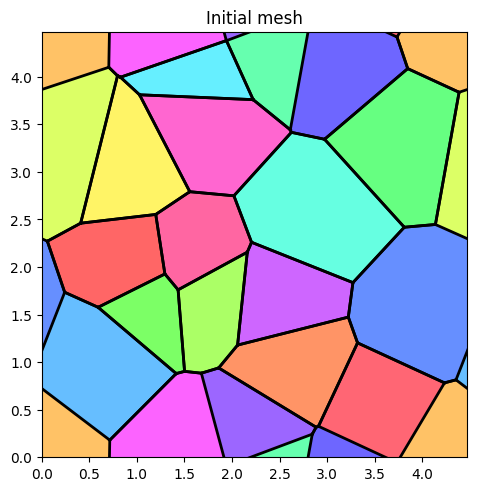

Created mesh has 20 cells, 60 edges and 40 vertices.


In [3]:
from vertax import plot_mesh

plot_mesh(mesh, title="Initial mesh")

print(f"Created mesh has {mesh.nb_faces} cells, {mesh.nb_edges} edges and {mesh.nb_vertices} vertices.")

The mesh is associated to parameters on vertices, (half-)edges and faces (cells). The meaning of these parameters is "given" by the loss functions.

In our example, we'll only focus on the parameters of the edges, which will be the tensions at given edge ; and the parameters for faces will be their area, fixed to 1.

In [4]:
import jax  # VertAX uses jax and manipulates jax arrays.
import jax.numpy as jnp  # Use it like numpy

# Set mesh parameters
# 1) We don't use vertices, basic initialization.
mesh.vertices_params = jnp.asarray([0.0 for _ in range(mesh.nb_vertices)])

# 2) We give a random tension to each edge.
mu_tensions = 1.2
std_tensions = 0.1

key = jax.random.PRNGKey(1)  # change the seed for different results
he_params = mu_tensions + std_tensions * jax.random.normal(key, shape=(mesh.nb_edges,))
# As we have half-edges, this part is necessary so that corresponding half-edges have the same tension.
mesh.edges_params = jnp.repeat(he_params, 2)

# 3) We set the faces areas to 1.
mesh.faces_params = jnp.asarray([1.0 for _ in range(mesh.nb_faces)])

It is time to define our custom inner loss function. This energy function will penalize cell areas different than 1 and the length of edges depending on the tension on them.

In [5]:
from jax import Array, vmap

from vertax.geo import get_area, get_length  # geometry functions to compute area of faces and length of edges
from vertax.opt import InnerLossFunction  # Only here for the type hint, not important

MAX_EDGES_IN_ANY_FACE = 20  # We make the assumption that a face will have less than 20 edges, for performance reasons.

def get_energy_function(
    reference_tension: float, width: float = width, height: float = height, max_iter: int = MAX_EDGES_IN_ANY_FACE
) -> InnerLossFunction:
    """Helper function to get a customized energy function."""

    # Energy functions : Note that they use the width and height parameters defined earlier
    def area_part(face: Array, face_param: Array, vertTable: Array, heTable: Array, faceTable: Array) -> Array:
        """Area part of the energy function, per given faces."""
        a = get_area(face, vertTable, heTable, faceTable, width, height, max_iter)
        return (a - face_param) ** 2

    def hedge_part(he: Array, he_param: Array, vertTable: Array, heTable: Array, faceTable: Array) -> Array:
        """Half-edges take part to the energy function too."""
        edge_lengths = get_length(he, vertTable, heTable, faceTable, width, height)
        return he_param * edge_lengths

    # It is important to define the energy function with this exact signature,
    # even though the "_vert_params" is unused, we still keep it.
    def energy_fct(
        vertTable: Array,
        heTable: Array,
        faceTable: Array,
        _vert_params: Array,
        he_params: Array,
        face_params: Array,
    ) -> Array:
        """Custom energy function for the inner optimization. All parameters are required in the signature."""
        K_areas = 20

        def mapped_areas_part(face: Array, face_param: Array) -> Array:
            return area_part(face, face_param, vertTable, heTable, faceTable)

        def mapped_hedges_part(he: Array, he_param: Array) -> Array:
            return hedge_part(he, he_param, vertTable, heTable, faceTable)

        areas_part = vmap(mapped_areas_part)(jnp.arange(len(faceTable)), face_params)
        hedges_part = vmap(mapped_hedges_part)(jnp.arange(2, len(heTable)), he_params[2:])
        return (
            (2 * reference_tension * get_length(0, vertTable, heTable, faceTable, width, height))
            + jnp.sum(hedges_part)
            + (0.5 * K_areas) * jnp.sum(areas_part)
        )

    return energy_fct

he_params_reference = float(he_params[0])  # The tensions are relative. Here we set a reference.
energy = get_energy_function(he_params_reference)

Now we are ready to perform the inner optimization ! This part is done by a PbcBilevelOptimizer, that stores hyper-parameters for the optimizations.

Here are some parameters that are taken into account with the inner optimization :

In [6]:
import optax  # Defines solvers for the optimization problems

bilevel_optimizer = PbcBilevelOptimizer()
bilevel_optimizer.loss_function_inner = energy  # Don't forget to set the loss function !
# Note: those are base values so the following can be ommited
bilevel_optimizer.inner_solver = optax.sgd(learning_rate=0.01)  # inner solver
bilevel_optimizer.update_T1 = True # Perform T1 transitions if necessary.
bilevel_optimizer.min_dist_T1 = 0.005  # Threshold to perform the T1 transitions.
bilevel_optimizer.max_nb_iterations = 1000  # Upper bound for the number of minimization operations
bilevel_optimizer.tolerance = 1e-4  # Below this level, we consider that the loss is stagnating
bilevel_optimizer.patience = 5  # Maximum number of consecutive stagnating loss before we stop.

Let's perform the inner optimization. It's as simple as that:

In [7]:
# Other paramerters are image_target (for cost_mesh2image), beta (for EP).
loss_history = bilevel_optimizer.inner_optimization(mesh)
# If you want to select only a subset of vertices, edges, and faces, it's possible:
# bilevel_optimizer.inner_optimization(mesh,
#     only_on_vertices=[list_vertex_ids],
#     only_on_edges=[list_edges_id],
#     only_on_faces=[list_faces_id],
# )

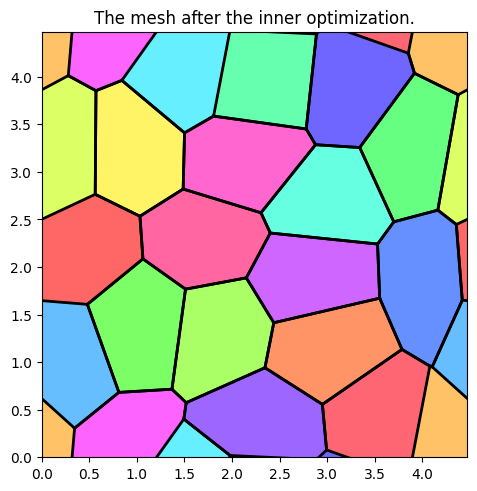

In [8]:
plot_mesh(mesh, title="The mesh after the inner optimization.")

The inner optimization nudged the mesh to minimize the length of edges with high tension while keeping the area of each face close to 1.

We'll use a bilevel optimization method to make this mesh correspond to another as much as possible, while keeping the constraints on the tensions and areas.

Let's set this "target" mesh.

The principle is the same :

In [9]:
# We copy all the parameters from previous mesh to create a new mesh.
target = PbcMesh.copy_mesh(mesh)

# We change the tensions (edges parameters) of the target mesh.
key = jax.random.PRNGKey(2)  # change the seed for different target tensions
he_params_target = mu_tensions + std_tensions * jax.random.normal(key, shape=(target.nb_edges,))
target.edges_params = jnp.repeat(he_params_target, 2)

he_params_reference_target = float(he_params_target[0])

# Energy minimization (target equilibrium)
target_loss_history = bilevel_optimizer.inner_optimization(target)



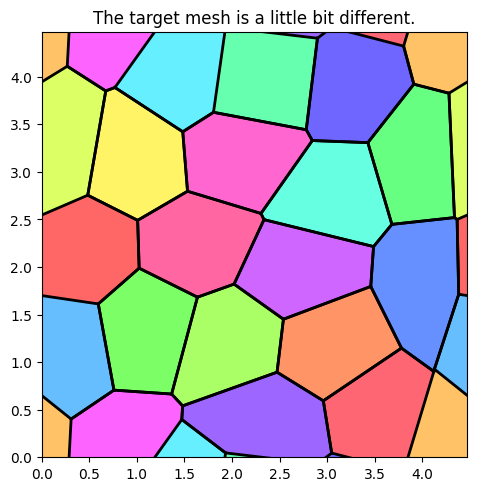

In [10]:
plot_mesh(target, title="The target mesh is a little bit different.")

OK now we obtained our target vertices, edges and faces, let's store them in our mesh : they become the mesh target.

In [11]:
bilevel_optimizer.vertices_target = target.vertices.copy()
bilevel_optimizer.edges_target = target.edges.copy()
bilevel_optimizer.faces_target = target.faces.copy()
# We can discard the target mesh now because it is of no use.
# del target

energy_target = get_energy_function(he_params_reference_target)
bilevel_optimizer.loss_function_inner = energy_target  # Update the inner loss function

In addition to the previous parameters for the inner optimization, the following parameters are used during the bilevel optimization process:

In [12]:
from vertax.cost import cost_v2v  # We use a loss function defined by vertax, but you can use yours.

# This one compute the distance of each vertices between the mesh and the target.
bilevel_optimizer.loss_function_outer = cost_v2v

from vertax import BilevelOptimizationMethod  # An enumeration of the methods you can use

# Once again this part can be ommited because those are the base value for these parameters
bilevel_optimizer.outer_solver = optax.adam(learning_rate=0.0001, nesterov=True)  # outer solver
bilevel_optimizer.bilevel_optimization_method = BilevelOptimizationMethod.EQUILIBRIUM_PROPAGATION

Let's run our bilevel optimization process. The first epoch is always a bit long but the next ones will be quick.

In a real simulation, a high number of epochs is necessary for a good result. Here, for this basic tutorial, we'll only use a few epochs.

(Also note that the performances are always worse in a notebook !)

In [39]:
from time import perf_counter

nb_epochs = 10

cost_history = []
for epoch in range(nb_epochs + 1):
    t_start = perf_counter()
    # The cost used compares the vertices positions only.
    # Other parameters are kept because it is important to always use the same signature function.
    cost = cost_v2v(
                mesh.vertices,
                mesh.edges,
                mesh.faces,
                mesh.width,
                mesh.height,
                bilevel_optimizer.vertices_target,
                bilevel_optimizer.edges_target,
                bilevel_optimizer.faces_target,
            )
    cost_history.append(cost)
    print(f"epoch: {epoch}/{nb_epochs}, actual cost is {cost}")

    loss_history = bilevel_optimizer.bilevel_optimization(mesh)
    print(f"epoch {epoch} took {perf_counter() - t_start} seconds.")
    pearson_corr = float(jnp.corrcoef(mesh.edges_params, target.edges_params)[0, 1])
    print(pearson_corr)

epoch: 0/10, actual cost is 0.0037211880553513765
epoch 0 took 1.2170525080000516 seconds.
-0.009380522184073925
epoch: 1/10, actual cost is 0.003721958724781871
epoch 1 took 1.1607601240002623 seconds.
-0.008781428448855877
epoch: 2/10, actual cost is 0.0037086878437548876
epoch 2 took 1.1663910829997803 seconds.
-0.008116534911096096
epoch: 3/10, actual cost is 0.003711005672812462
epoch 3 took 1.1220879219999915 seconds.
-0.007402104791253805
epoch: 4/10, actual cost is 0.0036993816029280424
epoch 4 took 1.1419530690000101 seconds.
-0.006774387322366238
epoch: 5/10, actual cost is 0.0037029192317277193
epoch 5 took 1.1655332840000483 seconds.
-0.0061574820429086685
epoch: 6/10, actual cost is 0.0036917426623404026
epoch 6 took 1.1711282279998159 seconds.
-0.0055525656789541245
epoch: 7/10, actual cost is 0.003695834195241332
epoch 7 took 1.146710374000122 seconds.
-0.004930838942527771
epoch: 8/10, actual cost is 0.003685095114633441
epoch 8 took 1.1108373649999521 seconds.
-0.00427

Just to check that the process is working, let's do a basic plot of the cost in function of the epoch.

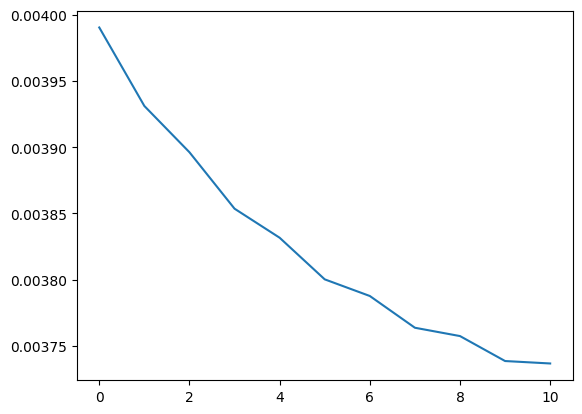

In [14]:
import matplotlib.pyplot as plt

plt.plot(range(nb_epochs+1), cost_history)
plt.show()

Of course, a higher number of epochs is necessary for the cost function to stabilize and for a result to be visible in the mesh. If we plot the mesh after a sufficient number of epochs, we'll see that the vertices moved to match the best it can the target while respecting tensions and area constraints.

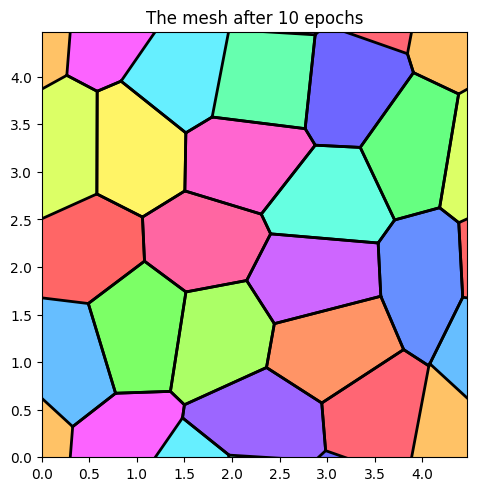

In [15]:
plot_mesh(mesh, title=f"The mesh after {nb_epochs} epochs")

We can also plot the tensions and areas:

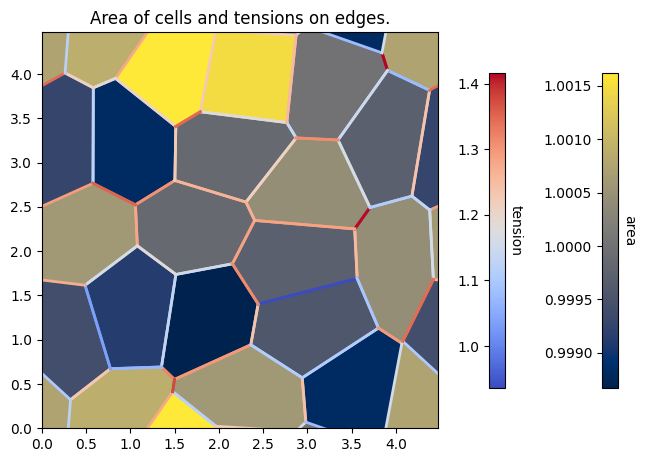

In [16]:
from vertax import EdgePlot, FacePlot, VertexPlot  # Enumerations to decide what to show on the plot.

plot_mesh(mesh, edge_plot=EdgePlot.EDGE_PARAMETER, edge_parameters_name="tension",
          face_plot=FacePlot.FACE_PARAMETER, face_parameters_name="area",
          vertex_plot=VertexPlot.INVISIBLE,
          title="Area of cells and tensions on edges.")

In [36]:
pearson_corr = float(jnp.corrcoef(mesh.faces_params, target.faces_params)[0, 1])
print(pearson_corr)
print(target.faces_params)
print(mesh.faces_params)
print(len(mesh.faces_params))
print(len(target.faces_params))
print((jnp.corrcoef(mesh.faces_params, target.faces_params)))
print((jnp.cov(mesh.faces_params, target.faces_params)))

nan
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[1.0005894  0.999558   1.0007367  0.99882126 0.9992633  0.9986739
 0.99911594 0.9997053  1.0014734  1.000442   1.0016208  0.9994106
 1.000442   1.         1.0005894  0.9997053  1.000884   0.99985266
 0.99985266 0.99882126]
20
20
[[ 1. nan]
 [nan nan]]
1.0
[[7.2733764e-07 0.0000000e+00]
 [0.0000000e+00 0.0000000e+00]]


In [38]:
pearson_corr = float(jnp.corrcoef(mesh.edges_params, target.edges_params)[0, 1])
print(pearson_corr)

-0.009977000765502453
